In [169]:
import yfinance as yf
import numpy as np
import pandas as pd
import pandas_ta as ta
from datetime import datetime
from ta.trend import MACD
from ta.momentum import RSIIndicator
import matplotlib.pyplot as plt

**Global Constants**

In [186]:
start_date, end_date = datetime(2022,10,1), datetime(2024,10,1)

series_tickers = ['BTC-USD', 'ETH-USD', 'DOGE-USD']

initial_capital = 100.0

rsi_threshold = 48

risk_free_rate = 0.04

**Backtest**

In [194]:
def backtest(close_prices: pd.Series, initial_capital: float) -> pd.Series:
    data = {}

    macd = MACD(close_prices, window_slow=26, window_fast=12, window_sign=9)
    data["macd"] = macd.macd() 
    data["signal"] = macd.macd_signal()

    rsi = RSIIndicator(close_prices, window=14)
    data["rsi"] = rsi.rsi() 

    equity = [0 for _ in range(len(close_prices))]
    num = 0.0
    in_position = False
    num_trades = 0
    for i in range(len(close_prices)):
        if i < 25:  # MA not shaped yet!
            equity[i] = initial_capital
            continue

        if not in_position:
            if data["macd"][i] > data["signal"][i] and data["macd"][i - 1] <= data["signal"][i - 1] and data["rsi"][i] > rsi_threshold:
                in_position = True
                num_trades += 1
                num = equity[i - 1] / close_prices[i]
                equity[i] = num * close_prices[i]
                # print("Buy at: ", close_prices[i])
                # print("Buy at: ", close_prices.index[i])
            else:
                equity[i] = equity[i - 1]

        else:
            equity[i] = num * close_prices[i]
            if data["macd"][i] < data["signal"][i] and data["macd"][i - 1] >= data["signal"][i - 1]:
                in_position = False
                num_trades += 1
                num = 0
                # print("Sell at: ", close_prices[i])
                # print("Sell at: ", close_prices.index[i])
    
    print(f"number of closed trades: {num_trades // 2}\topen trades: {num_trades % 2}")
    return pd.Series(equity, index=close_prices.index)

**Methods**

In [172]:
def net_profit(equity: pd.Series) -> float:
    return equity[-1] - initial_capital

In [173]:
def max_drawdown(equity: pd.Series) -> float:
    pv = equity.cummax()
    lp = equity.copy(deep=True)

    return ((lp - pv) / pv).min() * 100 

In [174]:
def drawdown_period(equity: pd.Series) -> int:
    cummax = -1
    cummax_t = -1
    max_drawdown_t = 0
    drawdown_period = None
    for i in range(len(equity)):
        if equity[i] >= cummax:
            cummax = equity[i]
            drawdown_days = (equity.index[i] - equity.index[cummax_t]).days
            if drawdown_days > max_drawdown_t:
                drawdown_period = (equity.index[cummax_t], equity.index[i])
            max_drawdown_t = max(max_drawdown_t, drawdown_days)  
            cummax_t = i

    print(f"max drawdown period is from ", end='')
    print(f"{drawdown_period[0].year}/{drawdown_period[0].month}/{drawdown_period[0].day} ", end='')
    print(f"to {drawdown_period[1].year}/{drawdown_period[1].month}/{drawdown_period[1].day}")
    return max_drawdown_t

In [175]:
def sharpe_ratio(equity: pd.Series) -> float:
    daily_returns = equity.pct_change().dropna()
    excess_returns = daily_returns - (risk_free_rate / 252)
    annualized_return = excess_returns.mean() * 252
    annualized_volatility = daily_returns.std() * np.sqrt(252)
    return annualized_return / annualized_volatility

In [176]:
def sortino_ratio(equity: pd.Series) -> float:
    daily_returns = equity.pct_change().dropna()
    excess_returns = daily_returns - (risk_free_rate / 252)
    downside_risk = daily_returns[daily_returns < 0].std() * np.sqrt(252)
    annualized_return = excess_returns.mean() * 252
    return annualized_return / downside_risk

**Plot Equity**

In [177]:
def plot_equity(coin, equity):
    equity.plot(title=f"{coin} Equity", ylabel="Value")
    equity.cummax().plot()
    plt.show()

**Driver**

Ticker:  BTC-USD
number of closed trades: 16	open trades: 1
max drawdown period is from 2023/7/3 to 2023/10/23
Net Profit: 65.65
Max Drawdown: -17.27%
Drawdown Period: 112
Sharpe Ratio: 0.76
Sortino Ratio: 0.71


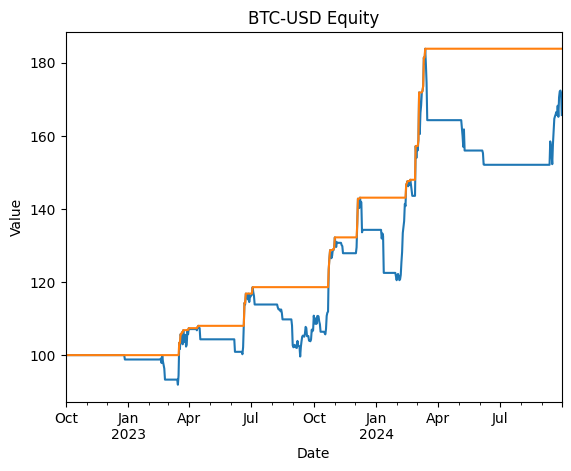

Ticker:  ETH-USD
number of closed trades: 16	open trades: 0
max drawdown period is from 2023/4/16 to 2023/11/9
Net Profit: 132.59
Max Drawdown: -21.83%
Drawdown Period: 207
Sharpe Ratio: 1.08
Sortino Ratio: 1.12


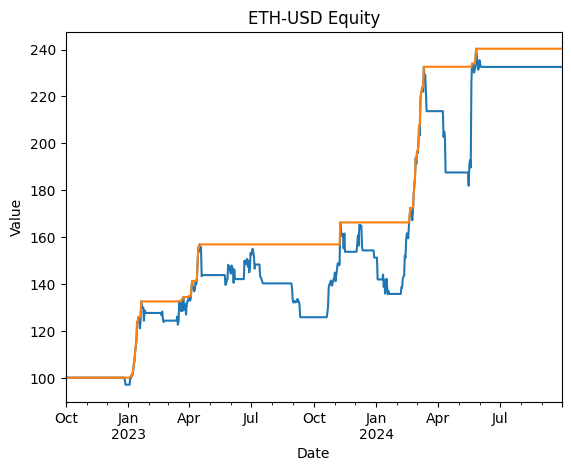

Ticker:  DOGE-USD
number of closed trades: 8	open trades: 1
max drawdown period is from 2022/11/30 to 2023/7/25
Net Profit: 96.24
Max Drawdown: -29.66%
Drawdown Period: 237
Sharpe Ratio: 0.69
Sortino Ratio: 0.61


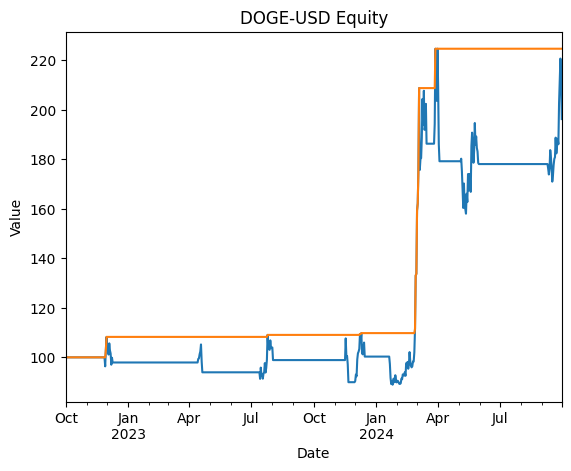

In [195]:
for ticker in series_tickers: 
    print("Ticker: ", ticker)
    prices = yf.Ticker(ticker).history(interval='1d', start=start_date, end=end_date).Close
    equity = backtest(prices, initial_capital)
    print(f'Net Profit: {round(net_profit(equity), 2)}\nMax Drawdown: {round(max_drawdown(equity), 2)}%\nDrawdown Period: {drawdown_period(equity)}\nSharpe Ratio: {round(sharpe_ratio(equity), 2)}\nSortino Ratio: {round(sortino_ratio(equity), 2)}')
    plot_equity(ticker, equity)
    print(50*"=")